In [2]:
%load_ext autoreload
%autoreload 2
from PyPDF2 import PdfReader
import os
import amrlib
import penman
import torch
from amrlib import load_stog_model
import networkx as nx
import sys, os
from pyvis.network import Network
import matplotlib.pyplot as plt
import amrlib
import spacy
from tools.sentence.sentence import Sentence
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from kg.formatting.formatting_manager import FormattingManager
import sys, importlib,os
sys.modules.pop('PatentTextFormatter', None)
importlib.invalidate_caches()
import numpy as np
from kg.cleaning.normalising.word_normaliser import WordNormaliser
from fastcoref import FCoref
import kg.cleaning.referencing.spacy_pipeline_patent
from tools.sentence.entity import Entity
import torch, os, platform
from kg.generating_kg.generating.NodeGenerator import NodeGenerator
import spacy
from kg.cleaning.referencing.spacy_pipeline_patent import SpacyPipeline

c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import torch, os, platform

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
print("torch.version.cuda:", torch.version.cuda)   # None == CPU-only build
print("gpu count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("name[0]:", torch.cuda.get_device_name(0))
    print("capability[0]:", torch.cuda.get_device_capability(0))
else:
    print("No CUDA device visible to PyTorch.")

torch: 2.7.1+cu128
cuda available: True
torch.version.cuda: 12.8
gpu count: 1
name[0]: NVIDIA GeForce RTX 5070 Ti
capability[0]: (12, 0)


In [4]:
formatterManager = FormattingManager()
segment_split = formatterManager.split_segments("A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.")
print("split" + str(segment_split))

11/23/2025 21:38:42 - INFO - 	 Use pytorch device_name: cuda:0
11/23/2025 21:38:42 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


split['A computing apparatus configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks based on predictive workload analysis, wherein said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.']


In [4]:
nlp = spacy.load("en_core_web_sm")
formatterManager = FormattingManager()
sentence_split = [[]]
for i in range(0,len(segment_split)):
    doc = nlp(segment_split[i])
    sentences = [sent.text.strip() for sent in doc.sents]
    sentence_str = ""
    for c in sentences:
        sentence_split[i].extend(formatterManager.split(c))

print(sentence_split[0])



11/23/2025 21:00:36 - INFO - 	 Use pytorch device_name: cuda:0
11/23/2025 21:00:36 - INFO - 	 Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2


State


11/23/2025 21:00:41 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Raw: ```json
[
  "A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.",
  "The allocation is based on predictive workload analysis.",
  "Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints."
]
``` State: {'text': 'A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks. Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', 'sentences': ['A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', 'The allocation is based on predictive workload analysis.', 'Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency co

11/23/2025 21:00:43 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Raw: ```json
[
  "A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.",
  "Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints."
]
``` State: {'text': 'A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks. Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', 'sentences': ['A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', 'The allocation is based on predictive workload analysis.', 'Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.'], 'improvement': None, 'done': True} iteration: 2


In [5]:
rule_based = [[]]
for i, c in enumerate(sentence_split):
    for d in c:
        print("Snip " + d.text)
        rule = formatterManager.rule_standardiser(
            d.text
        )
        rule_based[i].append(rule[i].text)  # replace the old element
print(sentence_split)
print(rule_based[0])


        



Snip A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.
Run sentence simplifier


11/23/2025 21:00:45 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:49 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:52 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Snip The allocation is based on predictive workload analysis.
Run sentence simplifier


11/23/2025 21:00:53 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


Snip Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.
Run sentence simplifier


11/23/2025 21:00:54 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:56 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"
11/23/2025 21:00:57 - INFO - 	 HTTP Request: POST https://api.anthropic.com/v1/messages "HTTP/1.1 200 OK"


[[Sentence(text='A computing apparatus is configured to dynamically allocate processing resources among a plurality of concurrent machine-learning inference tasks.', index=0, source='', span=None, id='d52cec49-95fe-49a3-bea5-b22b04ae466f', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='The allocation is based on predictive workload analysis.', index=1, source='', span=None, id='0bf1d41e-0b08-4919-abeb-c1935746ee04', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en'), Sentence(text='Said allocation is continuously optimized through feedback derived from real-time performance metrics and latency constraints.', index=2, source='', span=None, id='05217614-a925-4223-871d-9c026a315bd2', kg_node_id=None, embedding=None, tokens=[], entities={}, tags=[], importance=0.5, info_quality=0.5, novelty=None, lang='en')]]
['A computing a

In [6]:
print(rule_based[0][1])
for c,i in enumerate(rule_based):
    for i in rule_based[c]:
        simplify = formatterManager.simplify(i)
        print(simplify)



[GENERIC] Predictive workload analysis determines the allocation.
['a', 'computing', 'apparatus', 'dynamically', 'allocate', 'processing', 'resource', 'among', 'a', 'plurality', 'of', 'concurrent', 'machine', '-', 'learn', 'inference', 'task', '.']
['[', 'generic', ']', 'predictive', 'workload', 'analysis', 'determine', 'the', 'allocation', '.']
['[', 'assumption', ']', 'the', 'system', 'continuously', 'optimize', 'say', 'allocation', 'through', 'feedback', 'derive', 'from', 'real', '-', 'time', 'performance', 'metric', 'and', 'latency', 'constraint', '.']


In [7]:
# spacy_pipeline_patent.py (add this at the bottom, optional helper)

pipeline = SpacyPipeline()

sentence1 = Sentence(text="Caleb is soon 22.")
sentence2 = Sentence(text= "Caleb birthday is in half a year.")
sentence3 = Sentence(text="His brother is called Nathan.")
sentence4 = Sentence(text="Nathan is going to be 24 soon.")

sentences = [sentence1, sentence2, sentence3, sentence4]
joined_text = "".join(s.text for s in sentences)
doc = pipeline.nlp(joined_text)
sentence_starts = pipeline.indexes_sentences(sentences)
clusters = pipeline.fill_coref_entities(doc,sentence_starts, sentences)
cluster_spans = pipeline.get_cluster_spans(clusters)
pipeline.add_entities_from_ner(doc,cluster_spans=cluster_spans,sentence_starts=sentence_starts,sentences=sentences)
pipeline.normalise_other_refs_to_first(sentences)
pipeline.generate_normalised_text(sentences)

11/23/2025 21:03:20 - INFO - 	 missing_keys: []
11/23/2025 21:03:20 - INFO - 	 unexpected_keys: []
11/23/2025 21:03:20 - INFO - 	 mismatched_keys: []
11/23/2025 21:03:20 - INFO - 	 error_msgs: []
11/23/2025 21:03:20 - INFO - 	 Model Parameters: 90.5M, Transformer: 82.1M, Coref head: 8.4M
11/23/2025 21:03:20 - INFO - 	 Tokenize 1 inputs...
Map: 100%|██████████| 1/1 [00:00<00:00, 66.45 examples/s]
11/23/2025 21:03:21 - INFO - 	 ***** Running Inference on 1 texts *****
Inference: 100%|██████████| 1/1 [00:00<00:00, 13.31it/s]


Sentence 0: Caleb is soon 22.
  [0:5] Caleb Reference  ref=Caleb
Caleb is soon 22.
  [14:22] 22.Caleb PERSON  ref=22.Caleb
Caleb is soon 22.

Sentence 1: Caleb birthday is in half a year.
  [21:32] half a year DATE  ref=half a year
Caleb birthday is in half a year.

Sentence 2: Caleb brother is called Nathan.
  [0:3] His Reference  ref=Caleb
Caleb brother is called Nathan.
  [22:28] Nathan PERSON  ref=Nathan
Caleb brother is called Nathan.

Sentence 3: Nathan is going to be 24 soon.
  [0:6] Nathan PERSON  ref=Nathan
Nathan is going to be 24 soon.
  [22:24] 24 DATE  ref=24
Nathan is going to be 24 soon.


In [8]:

from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
DIM = model.get_sentence_embedding_dimension()

def embed_word(w: str) -> np.ndarray:
    v = model.encode(w, normalize_embeddings=True)
    return np.asarray(v, dtype="float32")

norm = WordNormaliser(embed_fn=embed_word, dim=DIM, threshold=0.72)


11/23/2025 21:03:26 - INFO - 	 Use pytorch device_name: cuda:0
11/23/2025 21:03:26 - INFO - 	 Load pretrained SentenceTransformer: all-MiniLM-L6-v2


In [9]:
amrlib.__file__
stog = amrlib.load_stog_model()


In [6]:

sentences_simpel = [
    '[_caleb123_person] is 21',
    '[_caleb123_person] lives in Munich',
    '[_caleb123_person] was born in Berlin',
    '[_nathan123_person] lives in Marburg',
    '[_nathan123_person] and [_caleb123_person] are brothers',
    '[_emma123_person] is 19',
    '[_emma123_person] studies biology',
    '[_emma123_person] lives in Berlin',
    '[_caleb123_person] and [_emma123_person] are friends',
    '[_nathan123_person] studies engineering',
    '[_caleb123_person] works at a bookstore',
    '[_emma123_person] likes music',
    '[_nathan123_person] likes football',
    '[_caleb123_person] and [_nathan123_person] play football together',
    '[_emma123_person] has a cat',
    '[_caleb123_person] likes [_emma123_person] cat',
    '[_nathan123_person] has a dog',
    '[_caleb123_person] and [_nathan123_person] walk the dog on weekends',
    '[_emma123_person] and [_caleb123_person] go to concerts',
    '[_caleb123_person] favorite band is Coldplay',
    '[_emma123_person] studies at Humboldt University',
    '[_nathan123_person] studies at Marburg University',
    'Caleb visits [_nathan123_person] in Marburg',
    '[_emma123_person] and [_nathan123_person] met last summer',
    '[_emma123_person] and [_caleb123_person] met at school',
    '[_caleb123_person] mother is a teacher',
    '[_nathan123_person] father is a doctor',
    '[_emma123_person] brother is 15',
    '[_caleb123_person] and [_nathan123_person] grew up in Berlin',
    '[_caleb123_person] moved to Munich last year',
    '[_nathan123_person] stayed in Marburg for his studies',
    'Emm[_emma123_person]a and [_nathan123_person] text often',
    '[_caleb123_person] calls [_emma123_person] on weekends',
    '[_nathan123_person] and [_caleb123_person] visit their parents in Berlin',
    '[_emma123_person] likes to travel',
    '[_caleb123_person] wants to visit Paris',
    '[_nathan123_person] visited Paris last year',
    '[_emma123_person] and [_caleb123_person] plan to visit Paris together',
    '[_caleb123_person] likes coffee',
    '[_emma123_person] prefers tea',
    '[_nathan123_person] drinks tea in the morning',
    '[_caleb123_person] and [_nathan123_person] share an apartment in summer',
    '[_emma123_person] comes over for dinner sometimes',
    '[_caleb123_person] cooks pasta often',
    '[_nathan123_person] helps with dishes',
    '[_emma123_person] brings dessert',
    '[_nathan123_person] and [_emma123_person] take photos together',
    '[_nathan123_person] posts photos on social media',
    '[_emma123_person] studies every morning',
    '[_caleb123_person] goes jogging in the park',
    '[_emma123_person] rides his bike to university'
]
sentences_patent_style = [
    'It is determined that the individual identified as [_caleb123_person] possesses an age of 21 years.',
    'The residence of [_caleb123_person] is established to be within the geographic region of [_munich_city].',
    'The origin of [_caleb123_person] is recorded as the municipality of [_berlin_city].',
    'The individual designated as [_nathan123_person] is located within the city of [_marburg_city].',
    'A fraternal relationship exists between [_nathan123_person] and [_caleb123_person].',
    'The individual referenced as [_emma123_person] possesses an age of 19 years.',
    '[_emma123_person] is engaged in an academic program in the field of [_biology_field].',
    '[_emma123_person] maintains a primary residence in the region of [_berlin_city].',
    'A social-association relationship is established between [_caleb123_person] and [_emma123_person].',
    '[_nathan123_person] is enrolled in a technical academic discipline identified as [_engineering_field].',
    '[_caleb123_person] performs occupational duties at the commercial establishment designated as [_bookstore_org].',
    'The individual [_emma123_person] exhibits a preference for the domain of [_music_field].',
    '[_nathan123_person] exhibits a preference for the activity identified as [_football_activity].',
    '[_caleb123_person] and [_nathan123_person] jointly participate in the activity of [_football_activity].',
    'The individual [_emma123_person] owns a domesticated animal classified as [_cat123_animal].',
    '[_caleb123_person] demonstrates a favorable disposition toward the [_cat123_animal] owned by [_emma123_person].',
    '[_nathan123_person] possesses a domesticated animal classified as [_dog123_animal].',
    '[_caleb123_person] and [_nathan123_person] engage in ambulatory activity with the [_dog123_animal] during weekends.',
    '[_emma123_person] and [_caleb123_person] participate together in attending musical-performance events.',
    'The preferred musical group of [_caleb123_person] is the entity designated as [_coldplay_band].',
    '[_emma123_person] conducts academic studies at the institution identified as [_humboldt_university].',
    '[_nathan123_person] conducts academic studies at the institution identified as [_marburg_university].',
    'The individual [_caleb123_person] performs visitation to [_nathan123_person] within the region of [_marburg_city].',
    '[_emma123_person] and [_nathan123_person] established initial contact during the temporal interval defined as last summer.',
    '[_emma123_person] and [_caleb123_person] initiated acquaintance during their attendance at [_school_generic].',
    'The maternal guardian of [_caleb123_person] is employed in the profession designated as [_teacher_profession].',
    'The paternal guardian of [_nathan123_person] is employed in the medical profession identified as [_doctor_profession].',
    'The brother of [_emma123_person] possesses an age of 15 years.',
    '[_caleb123_person] and [_nathan123_person] experienced upbringing within the region of [_berlin_city].',
    '[_caleb123_person] relocated to [_munich_city] during the previous calendar year.',
    '[_nathan123_person] remained within the region of [_marburg_city] for purposes associated with his academic studies.',
    '[_emma123_person] and [_nathan123_person] engage in text-based digital communication with high frequency.',
    '[_caleb123_person] establishes telephonic communication with [_emma123_person] during weekends.',
    '[_nathan123_person] and [_caleb123_person] conduct periodic parental visits within the region of [_berlin_city].',
    '[_emma123_person] exhibits a preference for travel-related activities.',
    '[_caleb123_person] expresses intent to conduct travel to [_paris_city].',
    '[_nathan123_person] conducted travel to [_paris_city] during the previous year.',
    '[_emma123_person] and [_caleb123_person] formulate a joint plan to conduct travel to [_paris_city].',
    '[_caleb123_person] demonstrates a preference for the consumable commodity identified as [_coffee_beverage].',
    '[_emma123_person] demonstrates a preference for the consumable commodity identified as [_tea_beverage].',
    '[_nathan123_person] consumes the beverage [_tea_beverage] during morning intervals.',
    '[_caleb123_person] and [_nathan123_person] occupy a shared residential unit during the summer season.',
    '[_emma123_person] performs occasional visitations for the purpose of participating in evening meals.',
    '[_caleb123_person] frequently prepares a food product categorized as [_pasta_food].',
    '[_nathan123_person] provides assistance with post-meal cleaning operations.',
    '[_emma123_person] supplies dessert items during shared meals.',
    '[_nathan123_person] and [_emma123_person] engage in photographic-capture activities together.',
    '[_nathan123_person] publishes said photographic content on digital social-media platforms.',
    '[_emma123_person] conducts academic study during morning intervals on a routine basis.',
    '[_caleb123_person] engages in jogging activity within the designated park region [_park_generic].',
    '[_emma123_person] utilizes a bicycle for transportation to the institution identified as [_humboldt_university].'
]


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Load the AMR model and move to GPU
stog = amrlib.load_stog_model()
if torch.cuda.is_available():
    stog.model.to('cuda')
    stog.device = torch.device('cuda')
else:
    stog.device = torch.device('cpu')

triples = []
for i in sentences_patent_style:
    triples_sin = NodeGenerator().run(i)
    triples.append(triples_sin)






KeyboardInterrupt: 

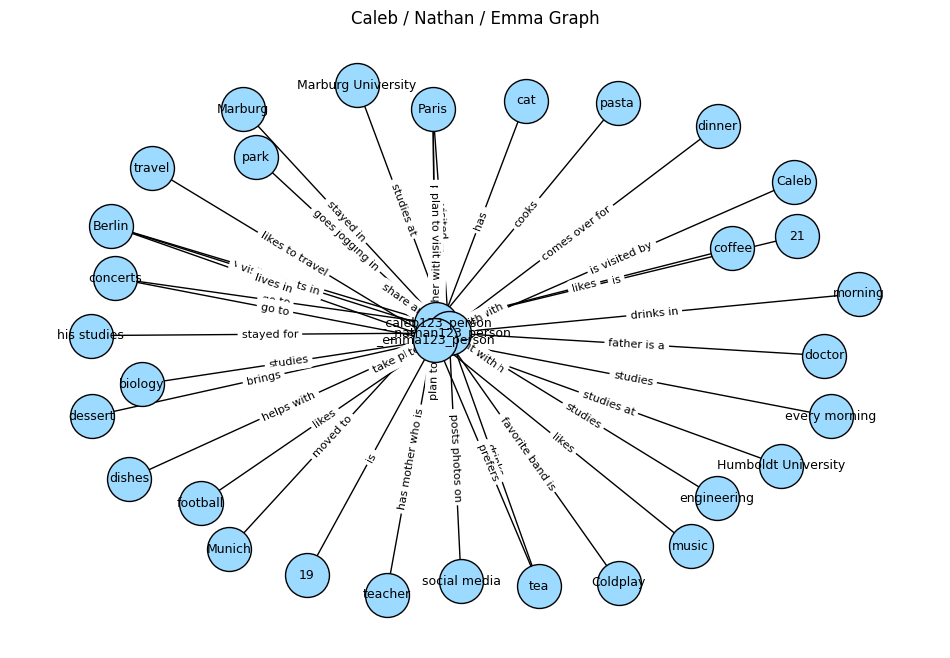

amr_graph.html
✅ Interactive graph written to amr_graph.html — open it in your browser.


In [35]:
import networkx as nx
import matplotlib.pyplot as plt
from pyvis.network import Network

# ---------------- Graph builder ----------------

def build_graph(triple_groups):
    """
    Create a directed NetworkX graph from:
      - a flat list of (head, relation, tail) triples, OR
      - a list of lists of triples (your current structure), with possible [].
    """
    G = nx.DiGraph()

    flat_triples = []

    for item in triple_groups:
        if not item:  # skip []
            continue

        # case 1: directly a triple: ('h', 'r', 't')
        if isinstance(item, tuple) and len(item) == 3:
            flat_triples.append(item)

        # case 2: list/iterable of triples, e.g. [ ('h','r','t'), ('h2','r2','t2') ]
        else:
            for triple in item:
                if isinstance(triple, tuple) and len(triple) == 3:
                    flat_triples.append(triple)

    # Now we have a clean flat list of triples
    for h, r, t in flat_triples:
        G.add_node(h)
        G.add_node(t)
        G.add_edge(h, t, label=r)

    return G


# ---------------- Matplotlib visualization ----------------

def visualize_matplotlib(G, title="Triple Graph"):
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(12, 8))
    nx.draw_networkx_nodes(G, pos, node_size=1000, node_color="#9ddaff", edgecolors="black")
    nx.draw_networkx_edges(G, pos, arrows=True)

    nx.draw_networkx_labels(G, pos, font_size=9)

    edge_labels = {(u, v): d["label"] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.show()


# ---------------- PyVis visualization (adapted) ----------------

def visualize_pyvis(G, out_file="graph.html"):
    # ---- PyVis interactive visualization ---- 
    net = Network(height="700px", width="100%", directed=True, notebook=True)
    net.barnes_hut()

    for n in G.nodes(data=False):
        net.add_node(
            n,
            label=n,
            color="#cbe5b6",
            shape="ellipse",
            title=f"id: {n}"
        )

    for u, v, d in G.edges(data=True):
        net.add_edge(
            u,
            v,
            label=d.get("label", ""),
            arrows="to"
        )

    net.show("amr_graph.html", notebook=None)
    print("✅ Interactive graph written to amr_graph.html — open it in your browser.")


# ---------------- Example with YOUR data ----------------

G = build_graph(triples)
visualize_matplotlib(G, title="Caleb / Nathan / Emma Graph")
visualize_pyvis(G)

In [26]:
# ---- PyVis interactive visualization ----
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    net.add_node(
    n,
    label=d.get("label") or d.get("concept") or n,
    color=d.get("color", "#cbe5b6"),
    shape="box" if d.get("shape") == "square" else "ellipse",
    title=f"id: {n}<br>kind: {d.get('kind', '')}"
)


for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html", notebook=None)
print("✅ Interactive graph written to amr_graph.html — open it in your browser.")


NameError: name 'nx_graph' is not defined

Each sentence converted to Sentence.py with all tokens in and tags like [Boilerplate] [Ambigous] or references like [1j123jS] = Main Device

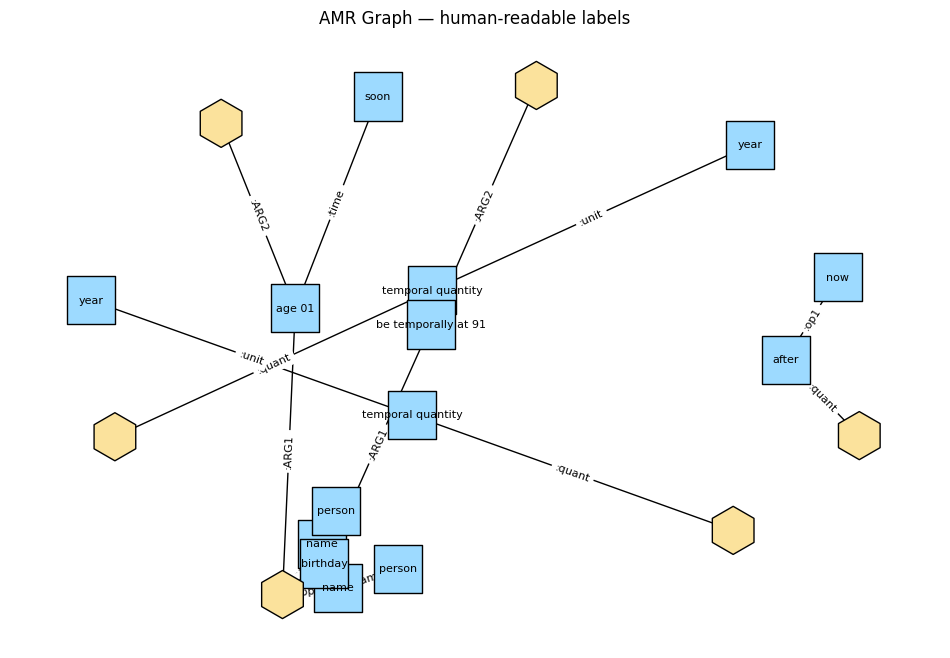

amr_graph.html
✅ Updated labels. Open amr_graph.html to explore interactively.


In [54]:
# --- Make node labels human-readable (use :name, :instance, :wiki) and re-render ---
from pyvis.network import Network
import re

# 1) Build helper maps from the PENMAN graph
inst = {s: t for s, r, t in g.triples if r == ":instance"}  # var -> concept

# Gather :name ops (op1/op2/...) and :wiki
name_parts = {}  # var -> [op1, op2, ...]
wiki = {}        # var -> "Qxxxx" or page

for s, r, t in g.triples:
    if r == ":wiki":
        wiki[s] = str(t).strip('"')
    elif r.startswith(":op"):
        # Only consider ops for nodes that have a :name relation
        # AMR often encodes names as: (x / person :name (n / name :op1 "John" :op2 "Doe"))
        # But in triple form, ops still reference the same source var as :name subtree var.
        name_parts.setdefault(s, []).append(str(t).strip('"'))
    elif r == ":name":
        # mark this var as having a name container; ops will attach to this var
        name_parts.setdefault(s, [])

# Also handle cases where name container is a separate var:
# If there are triples like (x :name n) and (n :op1 "Foo"), re-map ops from 'n' to 'x'.
name_container_edges = [(s, t) for s, r, t in g.triples if r == ":name"]
container_to_host = {container: host for host, container in name_container_edges}
if container_to_host:
    remap = {}
    for var, parts in list(name_parts.items()):
        if var in container_to_host:
            host = container_to_host[var]
            remap.setdefault(host, [])
            remap[host].extend(parts)
            del name_parts[var]
    for host, parts in remap.items():
        name_parts.setdefault(host, []).extend(parts)

# 2) Compute a pretty label for each node
def pretty_label(var_id, data):
    kind = data.get("kind")
    concept = data.get("concept", "")
    parts = name_parts.get(var_id, [])
    name_str = " ".join(parts).strip()
    if kind == "literal":
        return concept  # literal node already stores the text as 'concept'
    # Prefer explicit name if present
    if name_str:
        return name_str
    # Fall back to concept, title-case for readability (avoid overdoing for acronyms)
    if concept:
        # keep hyphens/underscores readable
        return re.sub(r"[_-]+", " ", str(concept)).strip()
    # Final fallback: the variable ID itself
    return str(var_id)

# 3) Attach labels, wiki, and root flag to nodes
root_var = getattr(g, "top", None)
for n, d in nx_graph.nodes(data=True):
    d["label"] = pretty_label(n, d)
    if n in wiki:
        d["wiki"] = wiki[n]
    if root_var is not None and n == root_var:
        d["root"] = True

# 4) Quick static check with matplotlib labels = node['label']
pos = nx.spring_layout(nx_graph, seed=7)
plt.figure(figsize=(12, 8))
for kind, shape in {"concept": "s", "literal": "h", "other": "o"}.items():
    nodes = [n for n, d in nx_graph.nodes(data=True) if d.get("kind") == kind]
    if nodes:
        nx.draw_networkx_nodes(
            nx_graph, pos, nodelist=nodes,
            node_shape=shape,
            node_color=[nx_graph.nodes[n].get("color", "#cbe5b6") for n in nodes],
            node_size=1200, edgecolors="black",
        )

nx.draw_networkx_edges(nx_graph, pos, arrows=True, arrowstyle="-|>")
nx.draw_networkx_labels(nx_graph, pos,
                        labels={n: d.get("label", n) for n, d in nx_graph.nodes(data=True)},
                        font_size=8)
nx.draw_networkx_edge_labels(nx_graph, pos,
                             edge_labels={(u, v): d.get("role", "") for u, v, d in nx_graph.edges(data=True)},
                             font_size=8)
plt.title("AMR Graph — human-readable labels")
plt.axis("off")
plt.show()

# 5) PyVis interactive with nice tooltips
net = Network(height="700px", width="100%", directed=True, notebook=True)
net.barnes_hut()

for n, d in nx_graph.nodes(data=True):
    hover = (
        f"<b>id</b>: {n}"
        f"<br><b>concept</b>: {d.get('concept','')}"
        f"<br><b>label</b>: {d.get('label','')}"
        + (f"<br><b>wiki</b>: {d.get('wiki')}" if d.get("wiki") else "")
        + (f"<br><b>root</b>: {d.get('root')}" if d.get("root") else "")
    )
    net.add_node(
        n,
        label=d.get("label", str(n)),
        title=hover,
        color=d.get("color", "#cbe5b6"),
        shape="box" if d.get("shape") == "square" else ("hexagon" if d.get("shape") == "hexagon" else "ellipse"),
    )

for u, v, d in nx_graph.edges(data=True):
    net.add_edge(u, v, label=d.get("role", ""), arrows="to")

net.show("amr_graph.html" , notebook=None)
print("✅ Updated labels. Open amr_graph.html to explore interactively.")


In [14]:
import os, pyvis, jinja2, sys
print("pyvis:", pyvis.__version__, "->", pyvis.__file__)
print("jinja2:", jinja2.__version__)
# Check if the template exists on disk:
tmpl_dir = os.path.join(os.path.dirname(pyvis.__file__), "templates")
print("template dir exists:", os.path.isdir(tmpl_dir))
if os.path.isdir(tmpl_dir):
    print("has template.html:", os.path.isfile(os.path.join(tmpl_dir, "template.html")))


pyvis: 0.3.2 -> c:\Users\Caleb\Documents\LLM Patent Claim Generator Thesis\.venv\Lib\site-packages\pyvis\__init__.py
jinja2: 3.1.6
template dir exists: True
has template.html: True


In [ ]:
##traversing

